# RFM Analysis — Customer Segmentation

**RFM** groups customers by three behaviours taken from their own purchase history:

| | Question | Good looks like |
|---|---|---|
| **Recency** | How long since they last bought? | a small number |
| **Frequency** | How many times have they bought? | a large number |
| **Monetary** | How much margin have they generated? | a large number |

Each is scored 1–4 by quartile, the three scores are combined, and the combination maps to
one of 11 named segments — from *Platinum Customer* down to *Lost Customer*.

The output is one row per customer with a segment attached, which is what the Tableau
dashboard is built on.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

trans = pd.read_csv('Transactions_Cleaned.csv', parse_dates=['transaction_date'])
cust  = pd.read_csv('CustomerDemographic_Cleaned.csv')
addr  = pd.read_csv('CustomerAddress_Cleaned.csv')

print(f'transactions : {len(trans):,}')
print(f'customers    : {len(cust):,}')
print(f'addresses    : {len(addr):,}')

transactions : 19,801
customers    : 3,997
addresses    : 3,993


## 1. RFM Analysis

### 1.1 Merging the transaction and customer tables

Transactions are joined to demographics, then to addresses.

The address join is a **left** join for the reason set out in the address notebook: four
customers have no address on file, and an inner join would delete them without a word. They
keep their transactions and their segment; they are simply absent from the map.

In [2]:
df = trans.merge(cust, on='customer_id', how='inner')
df = df.merge(addr, on='customer_id', how='left')

print(f'{len(df):,} transaction rows after merging')
print(f'{df["customer_id"].nunique():,} distinct customers')
print(f'{df["state"].isna().sum():,} rows from customers with no address on file')

19,801 transaction rows after merging
3,490 distinct customers
28 rows from customers with no address on file


### 1.2 Building the RFM table

One row per customer, three measures.

**Reference date.** Recency is measured against the **last transaction in the dataset**, not
against today. The data ends in December 2017; using today's date would make every customer
look equally stale and the recency score would carry no information.

**Monetary is profit, not revenue.** A customer who spends heavily on low-margin stock is
worth less than the revenue figure suggests. Segmenting on margin targets the customers who
actually make the business money.

In [3]:
comparison_date = df['transaction_date'].max()
print('last transaction in the data:', comparison_date.date())

rfm = df.groupby('customer_id').agg(
    recency   = ('transaction_date', lambda d: (comparison_date - d.max()).days),
    frequency = ('product_id', 'count'),
    monetary  = ('Profit', 'sum'),
).reset_index()

print(f'\n{len(rfm):,} customers scored')
rfm.describe().T[['min', '25%', '50%', '75%', 'max']].round(2)

last transaction in the data: 2017-12-30

3,490 customers scored


,min,25%,50%,75%,max
customer_id,1.00,878.25,1751.50,2624.75,3500.00
recency,0.00,17.00,44.00,86.00,353.00
frequency,1.00,4.00,6.00,7.00,14.00
monetary,15.08,1828.66,2840.37,4147.64,11668.95


Note that `monetary` skips the 196 transactions whose `standard_cost` was missing, because a
margin cannot be computed for them. Those sales still count towards frequency — the purchase
happened, only its profitability is unknown.

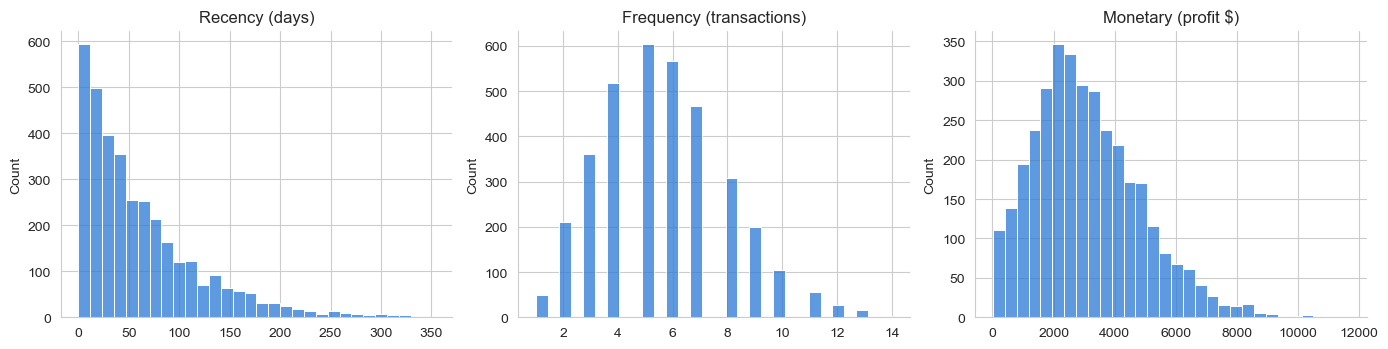

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, col, title in zip(axes, ['recency', 'frequency', 'monetary'],
                          ['Recency (days)', 'Frequency (transactions)', 'Monetary (profit $)']):
    sns.histplot(rfm[col], bins=30, color='#2a78d6', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
sns.despine()
plt.tight_layout()
plt.show()

### 1.3 Scoring each measure 1–4 by quartile

**Recency is reversed.** A low recency is good — the customer bought recently — so the labels
run `4,3,2,1` rather than `1,2,3,4`. Frequency and monetary run the natural way.

Get this backwards and the model recommends targeting the customers who left.

In [5]:
rfm['r_quartile'] = pd.qcut(rfm['recency'],   4, ['4', '3', '2', '1']).astype(int)
rfm['f_quartile'] = pd.qcut(rfm['frequency'], 4, ['1', '2', '3', '4']).astype(int)
rfm['m_quartile'] = pd.qcut(rfm['monetary'],  4, ['1', '2', '3', '4']).astype(int)

rfm[['recency', 'r_quartile', 'frequency', 'f_quartile', 'monetary', 'm_quartile']].head()

,recency,r_quartile,frequency,f_quartile,monetary,m_quartile
0,7,4,11,4,3018.09,3
1,128,1,3,1,2226.26,2
2,102,1,8,4,3362.81,3
3,195,1,2,1,220.57,1
4,16,4,6,2,2394.94,2


#### A limitation worth stating: frequency does not split into quartiles

`qcut` asks for four equal-sized groups. Recency and monetary are near-continuous so it gets
them. Frequency cannot be split this way — it takes only fourteen whole-number values across
thousands of customers, so thousands of people tie on the same value and cannot be separated.

In [6]:
print('distinct frequency values:', rfm['frequency'].nunique(),
      'across', f'{len(rfm):,}', 'customers\n')

sizes = rfm['f_quartile'].value_counts().sort_index()
pd.DataFrame({
    'customers': sizes,
    'share': (100 * sizes / len(rfm)).round(1),
    'if truly equal': [round(len(rfm)/4)] * 4,
})

distinct frequency values: 14 across 3,490 customers



,customers,share,if truly equal
f_quartile,,,
1,1139,32.6,872
2,1170,33.5,872
3,468,13.4,872
4,713,20.4,872


The groups come out badly uneven — one quartile holds roughly a third of all customers while
another holds a sixth.

**Why it matters:** the boundaries land wherever the ties happen to fall, so two customers one
transaction apart can end up in different quartiles while two customers three apart share one.
It also makes the result sensitive to the pandas version, since tie handling has changed over
time.

The method is kept as-is here so the segmentation stays comparable to the standard quartile
approach, but the effect is real and is repeated in the limitations at the end.

### 1.4 Combining into an RFM score

The three quartile scores are concatenated into a single three-digit number — recency in the
hundreds, frequency in the tens, monetary in the units. A customer scoring 4 on everything
reads as `444`; the weakest reads as `111`.

Recency therefore carries the most weight, which is deliberate: in retail, how recently
somebody bought is the strongest single predictor that they will buy again.

In [7]:
rfm['rfm_score'] = (100 * rfm['r_quartile']
                    + 10 * rfm['f_quartile']
                    +      rfm['m_quartile'])

print('distinct scores:', rfm['rfm_score'].nunique(), 'of a possible 64')
rfm['rfm_score'].value_counts().sort_index().head(10)

distinct scores: 62 of a possible 64


rfm_score
111    300
112    111
113     53
114      5
121     38
122     94
123     94
124     55
131      4
132     11
Name: count, dtype: int64

### 1.5 Mapping scores to 11 named segments

In [8]:
def segment_of(score):
    """Map an RFM score to a named segment, best to worst."""
    if score >= 444: return 'Platinum Customer'
    if score >= 433: return 'Very Loyal'
    if score >= 421: return 'Becoming Loyal'
    if score >= 344: return 'Recent Customer'
    if score >= 323: return 'Potential Customer'
    if score >= 311: return 'Late Bloomer'
    if score >= 224: return 'Losing Customer'
    if score >= 212: return 'High Risk Customer'
    if score >= 124: return 'Almost Lost Customer'
    if score >= 112: return 'Evasive Customer'
    return 'Lost Customer'


SEGMENT_ORDER = ['Platinum Customer', 'Very Loyal', 'Becoming Loyal', 'Recent Customer',
                 'Potential Customer', 'Late Bloomer', 'Losing Customer', 'High Risk Customer',
                 'Almost Lost Customer', 'Evasive Customer', 'Lost Customer']

rfm['customer_segment'] = rfm['rfm_score'].apply(segment_of)
rfm['segment_rank'] = rfm['customer_segment'].map(
    {name: i + 1 for i, name in enumerate(SEGMENT_ORDER)})

rfm.head()

,customer_id,recency,frequency,monetary,r_quartile,f_quartile,m_quartile,rfm_score,customer_segment,segment_rank
0,1,7,11,3018.09,4,4,3,443,Very Loyal,2
1,2,128,3,2226.26,1,1,2,112,Evasive Customer,10
2,3,102,8,3362.81,1,4,3,143,Almost Lost Customer,9
3,4,195,2,220.57,1,1,1,111,Lost Customer,11
4,5,16,6,2394.94,4,2,2,422,Becoming Loyal,3


## 2. Export for Tableau

One row per customer, carrying the segment plus every demographic and address field the
dashboard needs to filter on.

In [9]:
customer_level = (cust.merge(addr, on='customer_id', how='left')
                      .merge(rfm, on='customer_id', how='inner'))

customer_level['name'] = (customer_level['first_name'].fillna('') + ' '
                          + customer_level['last_name'].fillna('')).str.strip()

# Revenue as well as profit: the dashboard reports sales by segment, while the
# segmentation itself was scored on margin.
revenue = df.groupby('customer_id')['list_price'].sum().rename('total_sales')
customer_level = customer_level.merge(revenue, on='customer_id', how='left')

print(f'{len(customer_level):,} customers x {customer_level.shape[1]} columns')
print(f'total sales  : ${customer_level["total_sales"].sum():,.0f}')
print(f'total profit : ${customer_level["monetary"].sum():,.0f}')
customer_level.head()

3,490 customers x 29 columns
total sales  : $21,927,608
total profit : $10,818,682


,customer_id,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,owns_car,tenure,Age,Age Group,address,postcode,state,country,property_valuation,recency,frequency,monetary,r_quartile,f_quartile,m_quartile,rfm_score,customer_segment,segment_rank,name,total_sales
0,1,Laraine,Medendorp,Female,93,1953-10-12,Executive Secretary,Health,Mass Customer,Yes,11.0,64.0,60-69,060 Morning Avenue,2016.0,NSW,Australia,10.0,7,11,3018.09,4,4,3,443,Very Loyal,2,Laraine Medendorp,9084.45
1,2,Eli,Bockman,Male,81,1980-12-16,Administrative Officer,Financial Services,Mass Customer,Yes,16.0,37.0,30-39,6 Meadow Vale Court,2153.0,NSW,Australia,10.0,128,3,2226.26,1,1,2,112,Evasive Customer,10,Eli Bockman,4149.07
2,3,Arlin,Dearle,Male,61,1954-01-20,Recruiting Manager,Property,Mass Customer,Yes,15.0,64.0,60-69,NaN,NaN,NaN,NaN,NaN,102,8,3362.81,1,4,3,143,Almost Lost Customer,9,Arlin Dearle,9888.23
3,4,Talbot,NaN,Male,33,1961-10-03,Unknown,IT,Mass Customer,No,7.0,56.0,50-59,0 Holy Cross Court,4211.0,QLD,Australia,9.0,195,2,220.57,1,1,1,111,Lost Customer,11,Talbot,1047.72
4,5,Sheila-kathryn,Calton,Female,56,1977-05-13,Senior Editor,Unknown,Affluent Customer,Yes,8.0,41.0,40-49,17979 Del Mar Point,2448.0,NSW,Australia,4.0,16,6,2394.94,4,2,2,422,Becoming Loyal,3,Sheila-kathryn Calton,5903.20


In [10]:
customer_level.to_csv('Customer_Trans_RFM_Analysis.csv', index=False)
print('saved Customer_Trans_RFM_Analysis.csv')

saved Customer_Trans_RFM_Analysis.csv


## 3. Data Analysis and Exploration

The segmentation above is scored on behaviour. This section looks at *who* the customers
are, comparing the **3,997 existing customers** against the **1,000 new prospects** the
business has not sold to yet.

Note the two populations are different sizes and different things: existing customers have a
purchase history, prospects have none. Every chart below shows them side by side rather than
pooled, because a difference between the two groups is exactly what would change who gets
marketed to.

In [11]:
new_cust = pd.read_csv('NewCustomerList_Cleaned.csv')
old_cust = cust.copy()

print(f'existing customers : {len(old_cust):,}')
print(f'new prospects      : {len(new_cust):,}')

AGE_ORDER = ['Under 20', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
OLD_C, NEW_C = '#2a78d6', '#eb6834'

existing customers : 3,997
new prospects      : 1,000


### 3.1 Age distribution — existing customers vs new prospects

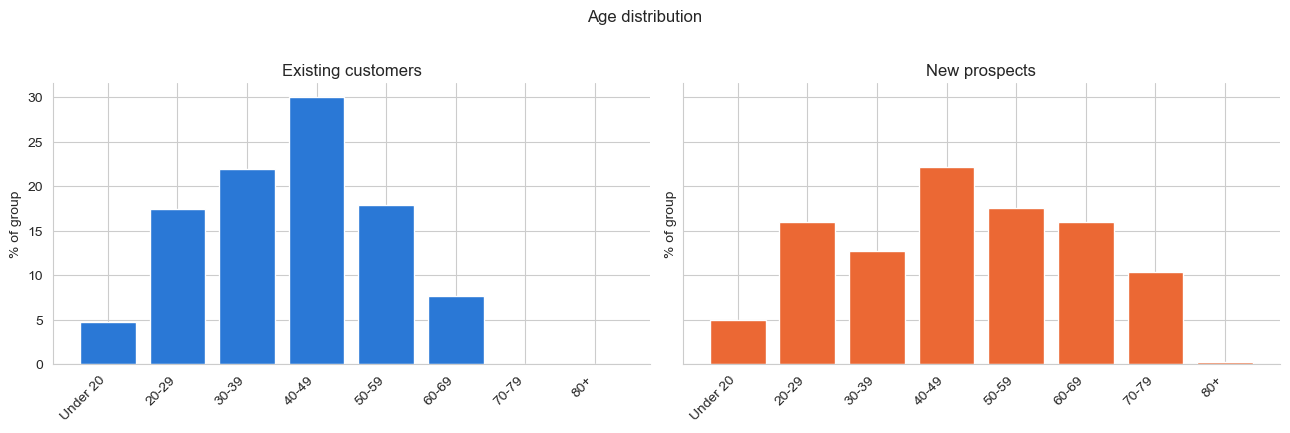

,existing %,prospects %
Age Group,,
Under 20,4.8,5.0
20-29,17.5,16.0
30-39,22.0,12.7
40-49,30.1,22.2
50-59,17.9,17.6
60-69,7.6,16.0
70-79,0.1,10.4
80+,0.1,0.2


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)

for ax, data, colour, title in [(axes[0], old_cust, OLD_C, 'Existing customers'),
                                (axes[1], new_cust, NEW_C, 'New prospects')]:
    order = [a for a in AGE_ORDER if a in data['Age Group'].dropna().unique()]
    counts = data['Age Group'].value_counts().reindex(order, fill_value=0)
    pct = 100 * counts / counts.sum()
    ax.bar(range(len(pct)), pct.values, color=colour)
    ax.set_xticks(range(len(pct)))
    ax.set_xticklabels(pct.index, rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel('% of group')

fig.suptitle('Age distribution', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

# Shown as a share of each group, not a raw count — the two populations are
# 3,997 and 1,000, so raw bars would compare group size rather than age.
pd.DataFrame({
    'existing %': (100 * old_cust['Age Group'].value_counts(normalize=True)).round(1),
    'prospects %': (100 * new_cust['Age Group'].value_counts(normalize=True)).round(1),
}).reindex(AGE_ORDER).dropna(how='all')

### 3.2 Bike-related purchases over the last 3 years, by gender

`past_3_years_bike_related_purchases` is a **self-reported customer attribute**, not a count
of transactions in this dataset. It covers a different period from the 2017 transaction
window and the two must never be added together.

In [13]:
by_gender = (old_cust.groupby('gender')['past_3_years_bike_related_purchases']
                     .agg(['sum', 'mean', 'count']))
by_gender.columns = ['total_purchases', 'avg_per_customer', 'customers']
by_gender['share_of_purchases_%'] = (100 * by_gender['total_purchases']
                                     / by_gender['total_purchases'].sum()).round(1)
by_gender.round(1)

,total_purchases,avg_per_customer,customers,share_of_purchases_%
gender,,,,
Female,98277,48.2,2038,50.3
Male,93392,49.9,1872,47.8
Unknown,3659,42.1,87,1.9


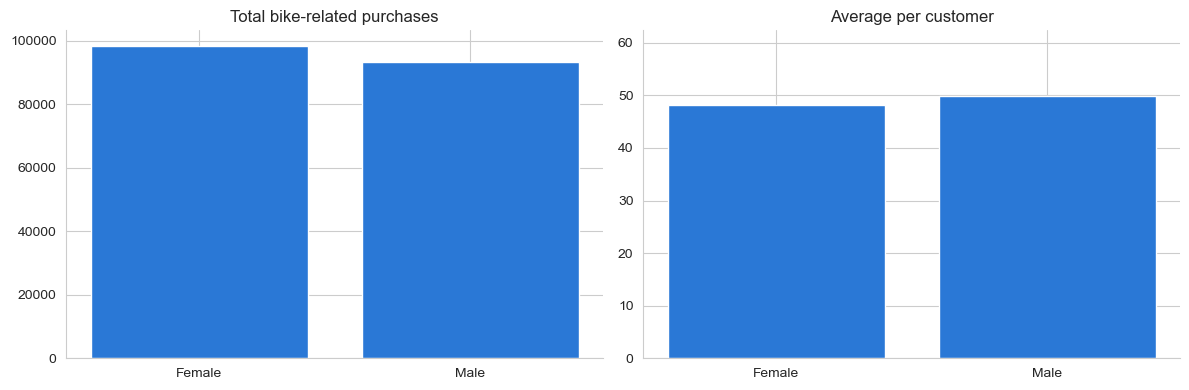

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

g = by_gender.drop(index='Unknown', errors='ignore')
axes[0].bar(g.index, g['total_purchases'], color=OLD_C)
axes[0].set_title('Total bike-related purchases')

axes[1].bar(g.index, g['avg_per_customer'], color=OLD_C)
axes[1].set_title('Average per customer')
axes[1].set_ylim(0, g['avg_per_customer'].max() * 1.25)

sns.despine()
plt.tight_layout()
plt.show()

**Read the right-hand chart, not the left.** Women account for more total purchases simply
because there are more women in the customer base. Per customer the two are almost identical,
so gender is not a useful targeting variable here — reporting the totals alone would imply a
difference that the averages show is not there.

### 3.3 Job industry distribution

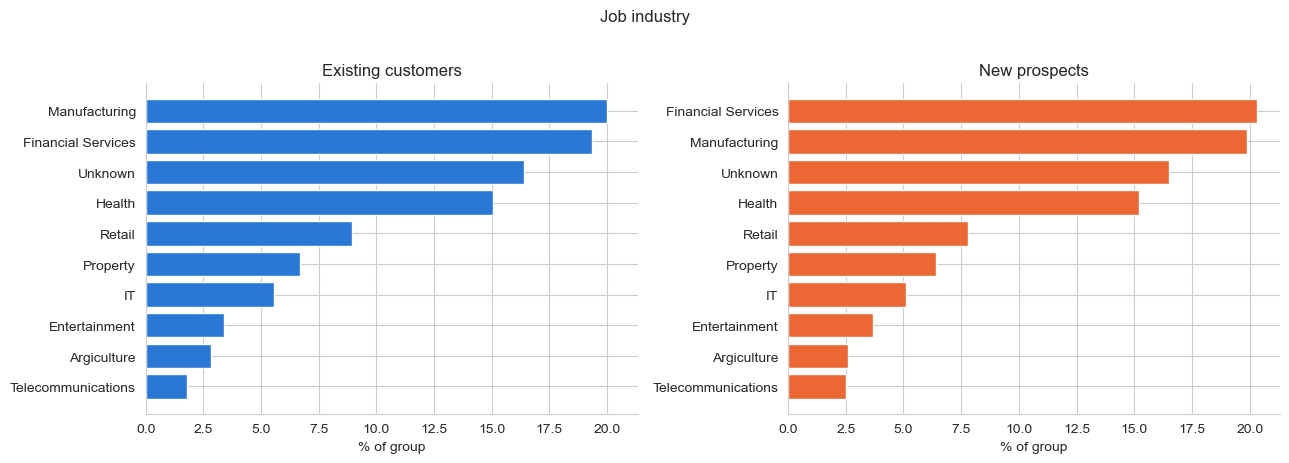

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)

for ax, data, colour, title in [(axes[0], old_cust, OLD_C, 'Existing customers'),
                                (axes[1], new_cust, NEW_C, 'New prospects')]:
    pct = 100 * data['job_industry_category'].value_counts(normalize=True)
    pct = pct.sort_values()
    ax.barh(pct.index, pct.values, color=colour)
    ax.set_title(title)
    ax.set_xlabel('% of group')

fig.suptitle('Job industry', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

`Unknown` is one of the larger bars in both groups — 16% of existing customers and 17% of
prospects have no industry recorded. It is shown rather than hidden: dropping it would make
every other share look bigger than it is.

### 3.4 Wealth segment by age group

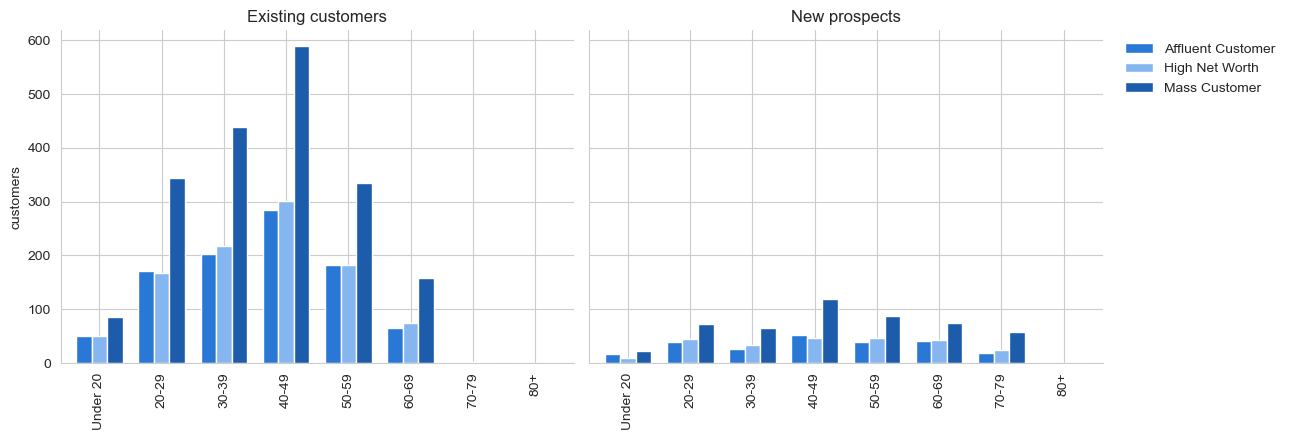

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, data, title in [(axes[0], old_cust, 'Existing customers'),
                        (axes[1], new_cust, 'New prospects')]:
    ct = pd.crosstab(data['Age Group'], data['wealth_segment'])
    ct = ct.reindex([a for a in AGE_ORDER if a in ct.index])
    ct.plot(kind='bar', stacked=False, ax=ax, width=0.75,
            color=['#2a78d6', '#86b6ef', '#1c5cab'], legend=(ax is axes[1]))
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('customers')

axes[1].legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

Mass Customer is the largest wealth segment in every age band, in both groups — roughly half
of each. The customer base is not concentrated at the wealthy end, which matters for how the
top RFM segments should be interpreted: a Platinum customer here is a frequent buyer, not
necessarily a rich one.

### 3.5 Car ownership by state

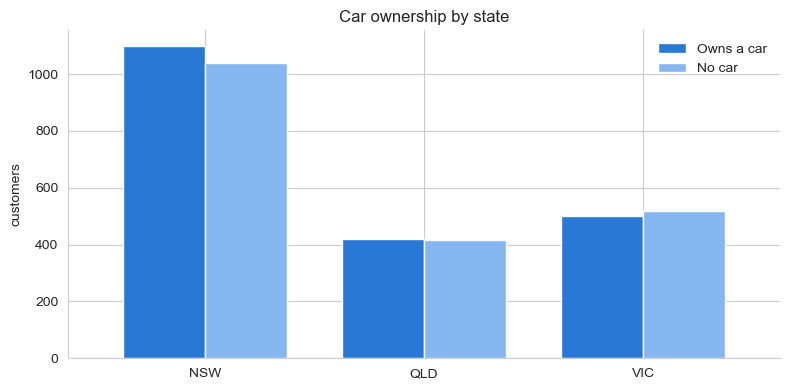

owns_car,No,Yes,% owning
state,,,
NSW,1038,1099,51.4
QLD,417,419,50.1
VIC,519,501,49.1


In [17]:
owners = (old_cust.merge(addr[['customer_id', 'state']], on='customer_id', how='inner')
                  .groupby(['state', 'owns_car']).size().unstack(fill_value=0))
owners['% owning'] = (100 * owners['Yes'] / owners.sum(axis=1)).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
owners[['Yes', 'No']].plot(kind='bar', ax=ax, width=0.75, color=['#2a78d6', '#86b6ef'])
ax.set_title('Car ownership by state')
ax.set_xlabel('')
ax.set_ylabel('customers')
ax.legend(['Owns a car', 'No car'], frameon=False)
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

owners

Car ownership sits close to 50% in all three states — the split is even everywhere rather
than concentrated in one. Like gender, it separates the customer base into two halves of
similar size and similar behaviour, so it is a poor basis for targeting.

## 4. RFM Scatter Plots

The segments are defined by the scores, so these plots are a check that the definition
produces coherent groups rather than a discovery in themselves. If the colours were scattered
at random, the segmentation would be meaningless.

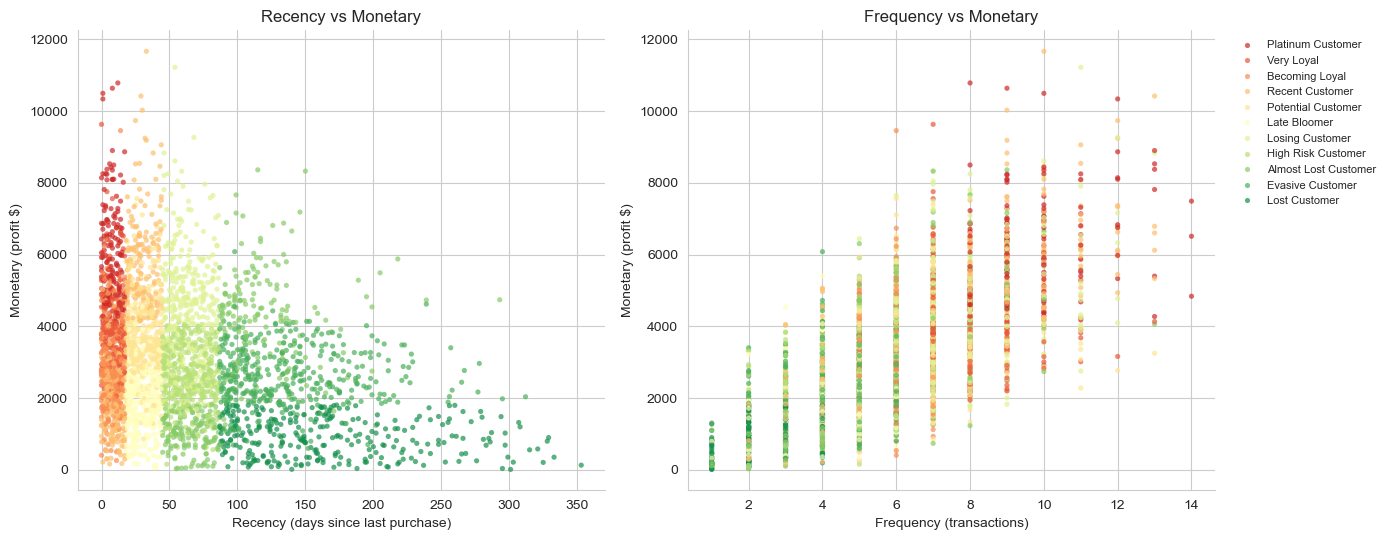

In [18]:
palette = dict(zip(SEGMENT_ORDER,
                   sns.color_palette('RdYlGn_r', n_colors=len(SEGMENT_ORDER))[::-1]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, x, xlabel in [(axes[0], 'recency', 'Recency (days since last purchase)'),
                      (axes[1], 'frequency', 'Frequency (transactions)')]:
    sns.scatterplot(data=rfm, x=x, y='monetary', hue='customer_segment',
                    hue_order=SEGMENT_ORDER, palette=palette, s=14,
                    alpha=0.7, linewidth=0, legend=(ax is axes[1]), ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Monetary (profit $)')

axes[0].set_title('Recency vs Monetary')
axes[1].set_title('Frequency vs Monetary')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

Recency vs Monetary shows the intended gradient — the best segments sit left (bought
recently) and high (profitable), the worst sit right and low.

Frequency vs Monetary shows the two are strongly related, which is expected: buying more
times generates more margin. It is worth noticing rather than glossing over, because it means
F and M are not independent inputs — a customer scoring well on one usually scores well on the
other, so the model has less information in it than three separate measures would suggest.

## 5. Customer Segment Distribution

In [19]:
summary = (rfm.groupby('customer_segment')
              .agg(customers=('customer_id', 'count'),
                   avg_recency=('recency', 'mean'),
                   avg_frequency=('frequency', 'mean'),
                   total_profit=('monetary', 'sum'))
              .reindex(SEGMENT_ORDER))

summary['share_%'] = (100 * summary['customers'] / summary['customers'].sum()).round(1)
summary['avg_recency'] = summary['avg_recency'].round(0)
summary['avg_frequency'] = summary['avg_frequency'].round(1)
summary['total_profit'] = summary['total_profit'].round(0)
summary

,customers,avg_recency,avg_frequency,total_profit,share_%
customer_segment,,,,,
Platinum Customer,168,8.0,9.5,1006523.0,4.8
Very Loyal,183,9.0,7.8,705727.0,5.2
Becoming Loyal,324,8.0,5.7,956587.0,9.3
Recent Customer,374,19.0,6.2,1411066.0,10.7
Potential Customer,359,31.0,6.7,1338821.0,10.3
Late Bloomer,356,30.0,4.2,683792.0,10.2
Losing Customer,347,63.0,7.7,1557803.0,9.9
High Risk Customer,368,64.0,4.9,956043.0,10.5
Almost Lost Customer,316,94.0,5.2,881650.0,9.1


The table reads top to bottom from best to worst, and the behaviour lines up with the names:
recency climbs and frequency falls as the segments get worse.

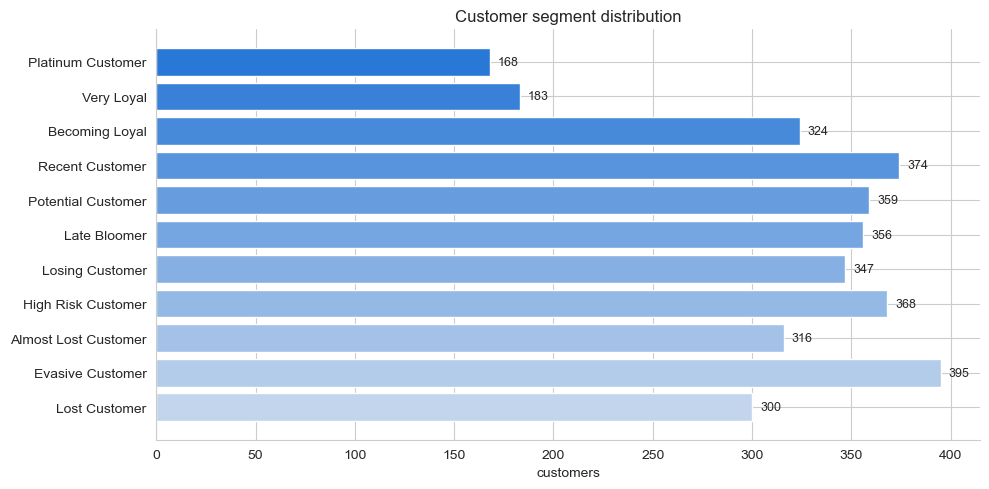

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

# One hue, dark to light, so position and shade both carry the ranking.
shades = sns.light_palette('#2a78d6', n_colors=len(SEGMENT_ORDER) + 3,
                           reverse=True)[:len(SEGMENT_ORDER)]
counts = summary['customers']

bars = ax.barh(range(len(counts)), counts.values, color=shades)
ax.set_yticks(range(len(counts)))
ax.set_yticklabels(counts.index)
ax.invert_yaxis()
ax.set_xlabel('customers')
ax.set_title('Customer segment distribution')
for i, v in enumerate(counts.values):
    ax.text(v + 4, i, f'{v:,}', va='center', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

## Summary

**Method**

| Step | Choice |
|---|---|
| Recency reference | last transaction in the data (Dec 2017), not today |
| Frequency | count of transactions per customer |
| Monetary | **profit**, not revenue — margin is what the business keeps |
| Scoring | quartiles 1–4, recency reversed |
| Combination | `100·R + 10·F + M`, so recency carries most weight |
| Segments | 11 named bands over the combined score |

**Limitations**

1. **Frequency will not quartile.** Only 14 distinct values across thousands of customers, so
   the four groups come out badly uneven and the boundaries fall wherever the ties do. This is
   the weakest part of the method.

2. **The combined score is a concatenation, not a magnitude.** Because segments are cut on
   ranges of `100·R + 10·F + M`, two very different customers can land in one band — a
   frequent, high-value customer who has drifted away scores 344, and a recent one-off buyer
   who spent almost nothing scores 411. Both are *Recent Customer*.

3. **Frequency and monetary are strongly correlated**, so the model carries less independent
   information than three measures imply.

4. **One year of transactions.** Recency, frequency and monetary are all measured over 2017
   alone, so a customer who bought heavily in 2016 and stopped looks identical to one who never
   bought at all.

5. **Segment boundaries are conventional, not derived.** The eleven thresholds come from common
   RFM practice rather than from anything in this data. A different set of cut-points would
   produce different segment sizes from exactly the same customers.